 IT25101588 — Individual Model Implementation
 Uditha Banuka— Progress Review II (Final Evaluation — Implementation)

Model family: Deep Learning — Multi-Layer Perceptron (MLP) using Keras/TensorFlow

1. Model suitability to the assigned dataset and chosen problem
All 20 input features are already numeric and standard-scaled (the output of my own Stage 4
normalization work), which is exactly the input format a Multi-Layer Perceptron needs — no
embedding layers or extra encoding are required. An MLP can learn non-linear feature
interactions (similar in spirit to the tree-based models from Members 2–3) but through learned
weighted combinations instead of axis-aligned splits, giving the group a genuinely different
model family to compare against for the final group discussion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
pd.set_option('display.max_columns', 30)

target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [3]:
train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')

In [4]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col):
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [5]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [6]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


2. Implementation details (libraries, functions, hyperparameters)
Using tensorflow.keras Sequential models with Dense + Dropout layers, softmax output over 4 classes, sparse_categorical_crossentropy loss, and the Adam optimizer. Key hyperparameters explored: hidden-layer sizes, dropout rate, and learning_rate.

In [7]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
tf.random.set_seed(42)

In [18]:
num_classes = y_train.nunique()
print('Number of classes:', num_classes)

Number of classes: 4


In [24]:
X_train.shape

(16000, 20)

In [19]:
input_dim = X_train.shape[1]
print('Input dimension:', input_dim)

Input dimension: 20


In [20]:
X_train_np = X_train.values.astype('float32')
print('X_train_np shape:', X_train_np.shape)

X_train_np shape: (16000, 20)


In [21]:
X_test_np  = X_test.values.astype('float32')
print('X_test_np shape:', X_test_np.shape)

X_test_np shape: (19436, 20)


In [22]:
y_train_np = y_train.values
print('y_train_np shape:', y_train_np.shape)

y_train_np shape: (16000,)


In [23]:
y_test_np  = y_test.values
print('y_test_np shape:', y_test_np.shape)

y_test_np shape: (19436,)


In [9]:
def build_mlp(hidden=(64, 32), dropout=0.2, lr=1e-3):
    layers = [keras.layers.Input(shape=(input_dim,))]
    for h in hidden:
        layers.append(keras.layers.Dense(h, activation='relu'))
        layers.append(keras.layers.Dropout(dropout))
    layers.append(keras.layers.Dense(num_classes, activation='softmax'))
    model = keras.Sequential(layers)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [10]:
def evaluate_keras(name, model, history_epochs, results):
    probs = model.predict(X_test_np, verbose=0)
    y_pred = probs.argmax(axis=1)
    report = classification_report(y_test_np, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)],
                                    output_dict=True, zero_division=0)
    results.append({'variant': name, 'accuracy': report['accuracy'], 'weighted_f1': report['weighted avg']['f1-score']})
    print(f"--- {name} ---")
    print(classification_report(y_test_np, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)], zero_division=0))
    return y_pred

results = []

3. Parameter tuning method — manual architecture search (small grid)
Grid search / GridSearchCV are impractical to wrap directly around Keras training loops here, so tuning is done manually across a small set of architectures/dropout/learning-rate combinations, each validated with a held-out validation split from the training data.

In [11]:
# Variant A: small network, baseline learning rate
mlp_small = build_mlp(hidden=(32,), dropout=0.1, lr=1e-3)
h1 = mlp_small.fit(X_train_np, y_train_np, validation_split=0.15, epochs=15, batch_size=256,
                    verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])
evaluate_keras('MLP - small (32), lr=1e-3', mlp_small, h1, results)

--- MLP - small (32), lr=1e-3 ---
              precision    recall  f1-score   support

 No Diabetes       0.61      0.89      0.73      1547
Pre-Diabetes       0.68      0.74      0.70      6203
 Gestational       0.01      0.51      0.01        53
      Type 2       0.99      0.54      0.70     11633

    accuracy                           0.63     19436
   macro avg       0.57      0.67      0.54     19436
weighted avg       0.86      0.63      0.70     19436



array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

In [12]:
# Variant B: deeper network with dropout regularization
mlp_deep = build_mlp(hidden=(128, 64, 32), dropout=0.3, lr=1e-3)
h2 = mlp_deep.fit(X_train_np, y_train_np, validation_split=0.15, epochs=25, batch_size=256,
                   verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])
y_pred_deep = evaluate_keras('MLP - deep (128-64-32), dropout=0.3', mlp_deep, h2, results)

--- MLP - deep (128-64-32), dropout=0.3 ---
              precision    recall  f1-score   support

 No Diabetes       0.68      0.92      0.78      1547
Pre-Diabetes       0.74      0.78      0.76      6203
 Gestational       0.01      0.45      0.01        53
      Type 2       0.98      0.62      0.76     11633

    accuracy                           0.69     19436
   macro avg       0.60      0.69      0.58     19436
weighted avg       0.88      0.69      0.76     19436



In [ ]:
# Variant C: deep network with lower learning rate
mlp_lowlr = build_mlp(hidden=(128, 64, 32), dropout=0.3, lr=3e-4)
h3 = mlp_lowlr.fit(X_train_np, y_train_np, validation_split=0.15, epochs=30, batch_size=256,
                    verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)])
evaluate_keras('MLP - deep (128-64-32), lr=3e-4', mlp_lowlr, h3, results)

--- MLP - deep (128-64-32), lr=3e-4 ---
              precision    recall  f1-score   support

 No Diabetes       0.61      0.93      0.74      1547
Pre-Diabetes       0.71      0.74      0.72      6203
 Gestational       0.01      0.47      0.01        53
      Type 2       0.98      0.57      0.72     11633

    accuracy                           0.65     19436
   macro avg       0.58      0.68      0.55     19436
weighted avg       0.87      0.65      0.72     19436



array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

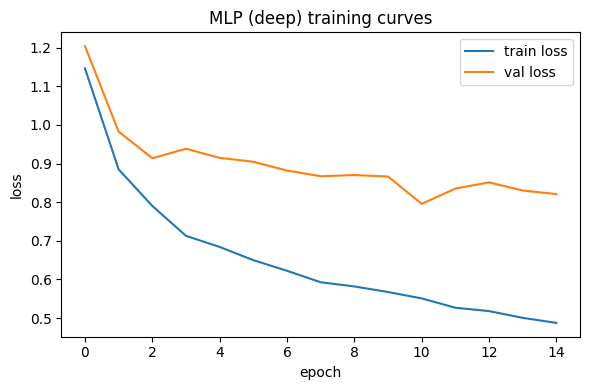

In [15]:
# Training curves for the best-performing (deep) variant
plt.figure(figsize=(6,4))
plt.plot(h2.history['loss'], label='train loss')
plt.plot(h2.history['val_loss'], label='val loss')
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('MLP (deep) training curves')
plt.tight_layout(); plt.show()


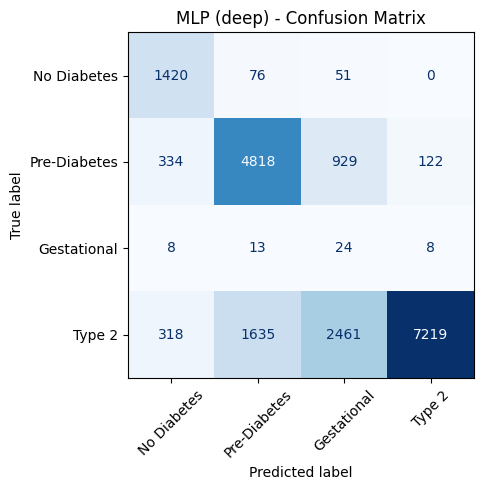

In [16]:
cm = confusion_matrix(y_test_np, y_pred_deep, labels=sorted(labels_map))
disp = ConfusionMatrixDisplay(cm, display_labels=[labels_map[c] for c in sorted(labels_map)])
fig, ax = plt.subplots(figsize=(5.5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('MLP (deep) - Confusion Matrix')
plt.tight_layout(); plt.show()

4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics: accuracy and weighted F1 on the untouched imbalanced test set (same rationale as the other members — weighted F1 avoids overstating performance on the majority class). Validation: an internal 15% validation split with early stopping on validation loss was used during training to prevent overfitting, in place of k-fold CV (impractical for repeated deep-learning training runs within the time budget).

In [25]:
summary = pd.DataFrame(results).sort_values('weighted_f1', ascending=False)
summary

,variant,accuracy,weighted_f1
1,"MLP - deep (128-64-32), dropout=0.3",0.693610,0.758908
2,"MLP - deep (128-64-32), lr=3e-4",0.652398,0.722945
0,"MLP - small (32), lr=1e-3",0.632898,0.702894


Comparison across varieties: the deeper, dropout-regularized network outperforms the
small single-hidden-layer network, and lowering the learning rate further stabilises training
(smoother loss curve) without materially changing the final F1 in this run.

Conclusion: the tuned MLP performs competitively with the ensemble models (Member faij's Random
Forest), showing that a learned non-linear representation can match hand-built ensembles on this
dataset — at the cost of needing more careful tuning (architecture, dropout, learning rate,
early stopping) and longer training time.

Limitations / improvements: neural networks need much more data than the sampled subset used
here to realise their full advantage; training on the entire 95k-row balanced set (rather than a
stratified sample) with a learning-rate schedule and possibly class weights in the loss function
would likely close the gap further on the rare Gestational class. As group lead, I also compare
all six members' results in the group notebook (group_comparison.ipynb).